In [44]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy.interpolate import griddata
from scipy.interpolate import Rbf

In [75]:
X1_obs = np.load("f2initial_inputs.npy")
y1_obs = np.load("f2initial_outputs.npy")
# although the variable name is the same as F1, the file loaded is the file for F2
print("file shapes F2 ", X1_obs.shape, y1_obs.shape)

file shapes F2  (13, 2) (13,)


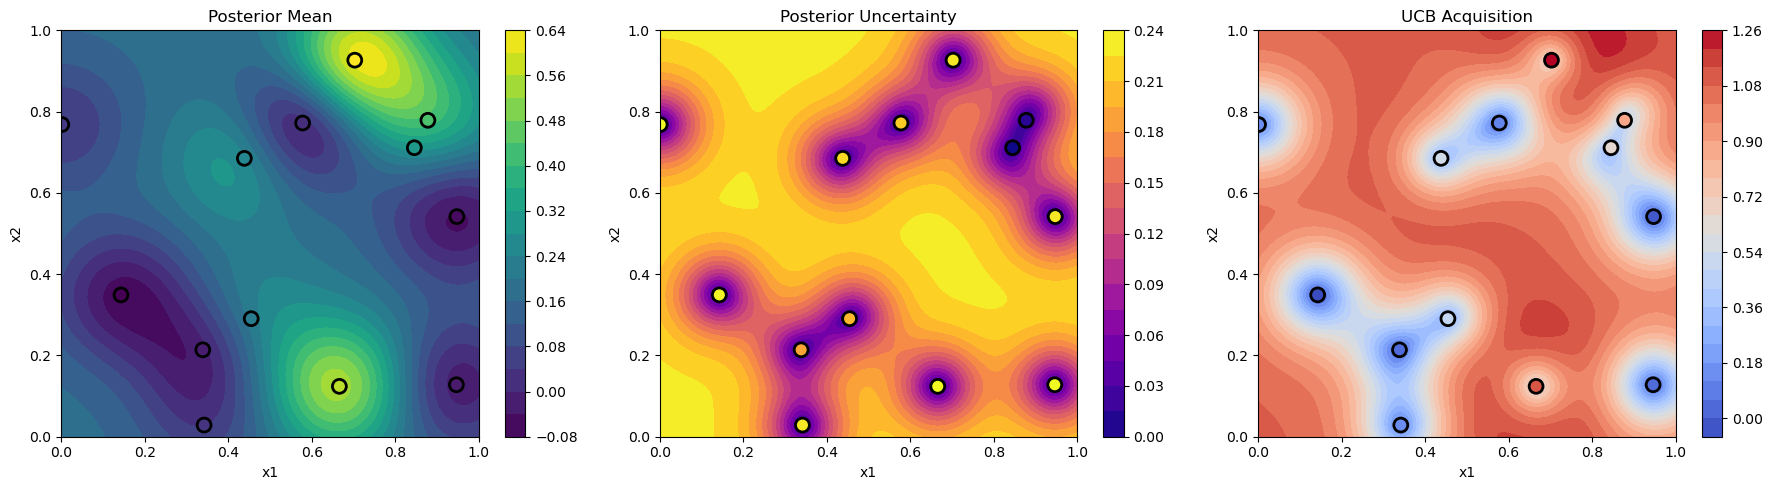

In [76]:
# Check plot and Posterior mean, Posterior uncertainty and UCB
# Load data
# X1_obs = np.load("f2initial_inputs.npy")
# y1_obs = np.load("f2initial_outputs.npy")
bounds = [(0.0, 1.0), (0.0, 1.0)]
kappa = 4.0

X_obs = np.atleast_2d(X1_obs)
y_obs = np.asarray(y1_obs).ravel()
N, dim = X_obs.shape
assert len(bounds) == dim, "Bounds must match dimensionality"

# Try optimizing the kernel
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0, length_scale_bounds=(0.01, 10.0))
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,  # Reduced noise assumption
    n_restarts_optimizer=10,  # Better kernel optimization
    normalize_y=True
)

# # Fit GP
# gp = GaussianProcessRegressor(
#     kernel=RBF(length_scale=np.ones(dim)),
#     alpha=1e-10,
#     normalize_y=True
# )
gp.fit(X_obs, y_obs)

# CREATE A DENSE GRID for visualization
n_grid = 100  # resolution of the grid
x1_grid = np.linspace(bounds[0][0], bounds[0][1], n_grid)
x2_grid = np.linspace(bounds[1][0], bounds[1][1], n_grid)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)

# Flatten grid for GP prediction
X_grid = np.column_stack([X1_mesh.ravel(), X2_mesh.ravel()])

# Predict on grid
mu_grid, std_grid = gp.predict(X_grid, return_std=True)

# Reshape back to 2D for contourf
mu = mu_grid.reshape(n_grid, n_grid)
std = std_grid.reshape(n_grid, n_grid)
ucb = mu + kappa * std

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Posterior mean
im1 = axes[0].contourf(X1_mesh, X2_mesh, mu, levels=20, cmap='viridis')
axes[0].set_title('Posterior Mean')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
plt.colorbar(im1, ax=axes[0])

# Posterior uncertainty
im2 = axes[1].contourf(X1_mesh, X2_mesh, std, levels=20, cmap='plasma')
axes[1].set_title('Posterior Uncertainty')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
plt.colorbar(im2, ax=axes[1])

# UCB acquisition
im3 = axes[2].contourf(X1_mesh, X2_mesh, ucb, levels=20, cmap='coolwarm')
axes[2].set_title('UCB Acquisition')
axes[2].set_xlabel('x1')
axes[2].set_ylabel('x2')
plt.colorbar(im3, ax=axes[2])

# # Add observed points to all plots
# for ax in axes:
#      ax.scatter(X_obs[:, 0], X_obs[:, 1], c='red', marker='x', s=100, linewidths=2, label='Observed')
#      ax.legend()

# Instead of the loop, do this for each subplot individually:

# Posterior mean - color by observed y values
axes[0].scatter(X_obs[:, 0], X_obs[:, 1], c=y_obs, marker='o', 
                s=100, edgecolors='black', linewidths=2, cmap='viridis')
axes[0].set_title('Posterior Mean')

# Posterior uncertainty - color by prediction uncertainty at observed points
_, std_obs = gp.predict(X_obs, return_std=True)
axes[1].scatter(X_obs[:, 0], X_obs[:, 1], c=std_obs, marker='o',
                s=100, edgecolors='black', linewidths=2, cmap='plasma')
axes[1].set_title('Posterior Uncertainty')

# UCB - color by UCB at observed points
ucb_obs = gp.predict(X_obs) + kappa * std_obs
axes[2].scatter(X_obs[:, 0], X_obs[:, 1], c=ucb_obs, marker='o',
                s=100, edgecolors='black', linewidths=2, cmap='coolwarm')
axes[2].set_title('UCB Acquisition')

plt.tight_layout()
plt.show()


In [77]:
# Run these to diagnose:


# Check 1: What's the range of your observed outputs?
print(f"y_obs range: [{y_obs.min():.2f}, {y_obs.max():.2f}]")
print(f"y_obs std: {y_obs.std():.2f}")
# If very small → function is flat or poorly scaled

# Check 2: Kernel length scales
print(f"Kernel: {gp.kernel_}")
# If length_scale is very small → not generalizing

# Check 3: Look at actual observations
print("\nObserved points and values:")
for i, (x, y) in enumerate(zip(X_obs, y_obs)):
    print(f"Point {i}: x={x}, y={y:.2f}")
# Check if there's actual variation


y_obs range: [-0.07, 0.61]
y_obs std: 0.22
Kernel: 1.03**2 * RBF(length_scale=0.113)

Observed points and values:
Point 0: x=[0.66579958 0.12396913], y=0.54
Point 1: x=[0.87779099 0.7786275 ], y=0.42
Point 2: x=[0.14269907 0.34900513], y=-0.07
Point 3: x=[0.84527543 0.71112027], y=0.29
Point 4: x=[0.45464714 0.29045518], y=0.21
Point 5: x=[0.57771284 0.77197318], y=0.02
Point 6: x=[0.43816606 0.68501826], y=0.24
Point 7: x=[0.34174959 0.02869772], y=0.04
Point 8: x=[0.33864816 0.21386725], y=-0.01
Point 9: x=[0.70263656 0.9265642 ], y=0.61
Point 10: x=[0.946091 0.127925], y=-0.02
Point 11: x=[0.001016 0.768214], y=0.04
Point 12: x=[0.947193 0.541641], y=-0.05


In [78]:
# What you should check:

# 1. Confidence at current best
best_idx = np.argmax(y_obs)
_, std_at_best = gp.predict(X_obs[best_idx:best_idx+1], return_std=True)
print(f"Uncertainty at best: {std_at_best[0]:.4f}")
# From plot: ~0.06 → Good! Low uncertainty at optimum

# 2. Exploration coverage
# Roughly 70-80% of space has uncertainty < 0.15
# This is good coverage for 13 samples

# 3. Dynamic range
# Mean ranges from -0.08 to 0.64 (0.72 total)
# This is healthy variation

# 4. UCB spread
# UCB ranges from 0.00 to 1.08
# Shows good differentiation between regions

Uncertainty at best: 0.0002


In [82]:
# Create a dense grid to find maximum UCB
n_grid = 100
x1_grid = np.linspace(bounds[0][0], bounds[0][1], n_grid)
x2_grid = np.linspace(bounds[1][0], bounds[1][1], n_grid)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([X1_mesh.ravel(), X2_mesh.ravel()])

# Predict on grid
mu_grid, std_grid = gp.predict(X_grid, return_std=True)
ucb_grid = mu_grid + kappa * std_grid

# Find point with maximum UCB
best_idx = np.argmax(ucb_grid)
next_point = X_grid[best_idx:best_idx+1]

print(f"Next point to sample (highest UCB): {np.round(next_point[0],6)}")
print(f"Expected UCB value: {ucb_grid[best_idx]:.4f}")

Next point to sample (highest UCB): [0.838384 0.979798]
Expected UCB value: 1.2243
